Hello, and welcome to my Week 5 homework! 

## Objective:

Our goal for this week is to consider what makes certain visualizations ineffective or misleading. We'll do this by finding a poorly designed chart in some data journal or article, recreating it in Python, then remodeling it to better fit its goal. This will help clarify exactly what aspects of visualization are the most important as well as demonstrate the need for well-informed design choices.

### Our "Culprit"

I decided to look for this dataset on Kaggle, as you can view different data journals that users have posted using that dataset. Furthermore, we can see the code that the users utilized to create charts, so it'll be easier to recreate the chart in Python. I discovered the following [dataset on NBA shot logs](https://www.kaggle.com/datasets/dansbecker/nba-shot-logs/data) on Kaggle; this dataset includes several datapoints that pertain to shots taken during the 2014-2015 NBA season, such as distance from the basket or whether defenders were near. Under the notebooks section, I found this journal called [NBA Dataset Modelling](https://www.kaggle.com/code/tolugboyega/nba-dataset-modelling) that walks through several different models using the data, including some really cool machine learning models. However, I noticed this chart that I found extremely confusing:

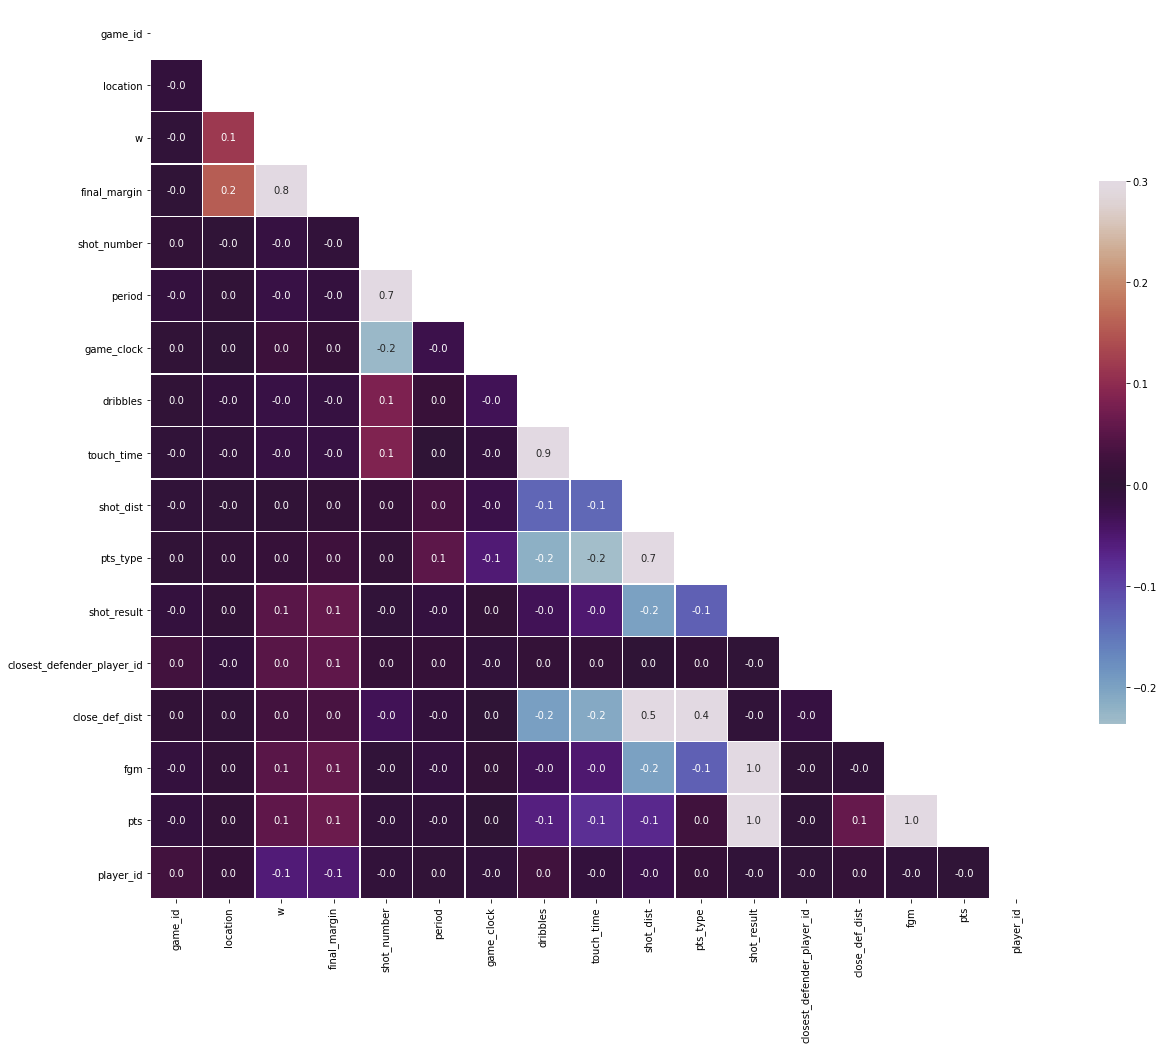

Conceptually, this is a super fascinating chart; the user computes a correlation matrix between every column of the dataset, resulting in a unique number that describes the correlation between every variable. Then, they create a heatmap with a staircase pattern to demonstrate the strength of every unique variable pairing, using color to indicate the strength and sign (positive or negative) of each relationship. However, I found the following issues with this visualization:

1. The user does not trim down variables; this chart should be limited to a specific subset of variables that we should consider to be at least somewhat correlated. Furthermore, they didn't even remove index variables like game ID and player ID, contributing to unnecessary visual clutter.
2. The color scheme is very misleading. While I like that red corresponds to a positive linear relationship and blue to a negative one, I don't feel like it makes sense for low or nonexistent correlations to correspond to black.
3. The axes use the variables original names, which can be kind of ugly and unclear exactly what they represent.

Here's how I propose to fix those issues:

1. Limit the amount of variables we include in our visualization to those where correlation is of interest (we're not interested in a correlation between game ID and shot distance)
2. Redo the color scale: have opacity/deepness of color describe the strength/magnitude of correlation, and opposite colors correspond to positive or negative
3. Redefine variables so column labels are more easily interpretable

Let's start by setting up our library, uploading the dataset, and recreating the chart

## Setup

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
from matplotlib.colors import LinearSegmentedColormap

In [2]:
shotlogs = pd.read_csv('shot_logs.csv')
shotlogs.head()

,GAME_ID,MATCHUP,LOCATION,W,FINAL_MARGIN,SHOT_NUMBER,PERIOD,GAME_CLOCK,SHOT_CLOCK,DRIBBLES,...,SHOT_DIST,PTS_TYPE,SHOT_RESULT,CLOSEST_DEFENDER,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,FGM,PTS,player_name,player_id
0,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,1,1,1:09,10.8,2,...,7.7,2,made,"Anderson, Alan",101187,1.3,1,2,brian roberts,203148
1,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,2,1,0:14,3.4,0,...,28.2,3,missed,"Bogdanovic, Bojan",202711,6.1,0,0,brian roberts,203148
2,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,3,1,0:00,NaN,3,...,10.1,2,missed,"Bogdanovic, Bojan",202711,0.9,0,0,brian roberts,203148
3,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,4,2,11:47,10.3,2,...,17.2,2,missed,"Brown, Markel",203900,3.4,0,0,brian roberts,203148
4,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,5,2,10:34,10.9,2,...,3.7,2,missed,"Young, Thaddeus",201152,1.1,0,0,brian roberts,203148


Now, to recreate the chart, we'll use the user's code directly and analyze exactly what they did:

## Original Chart Recreation

<Axes: >

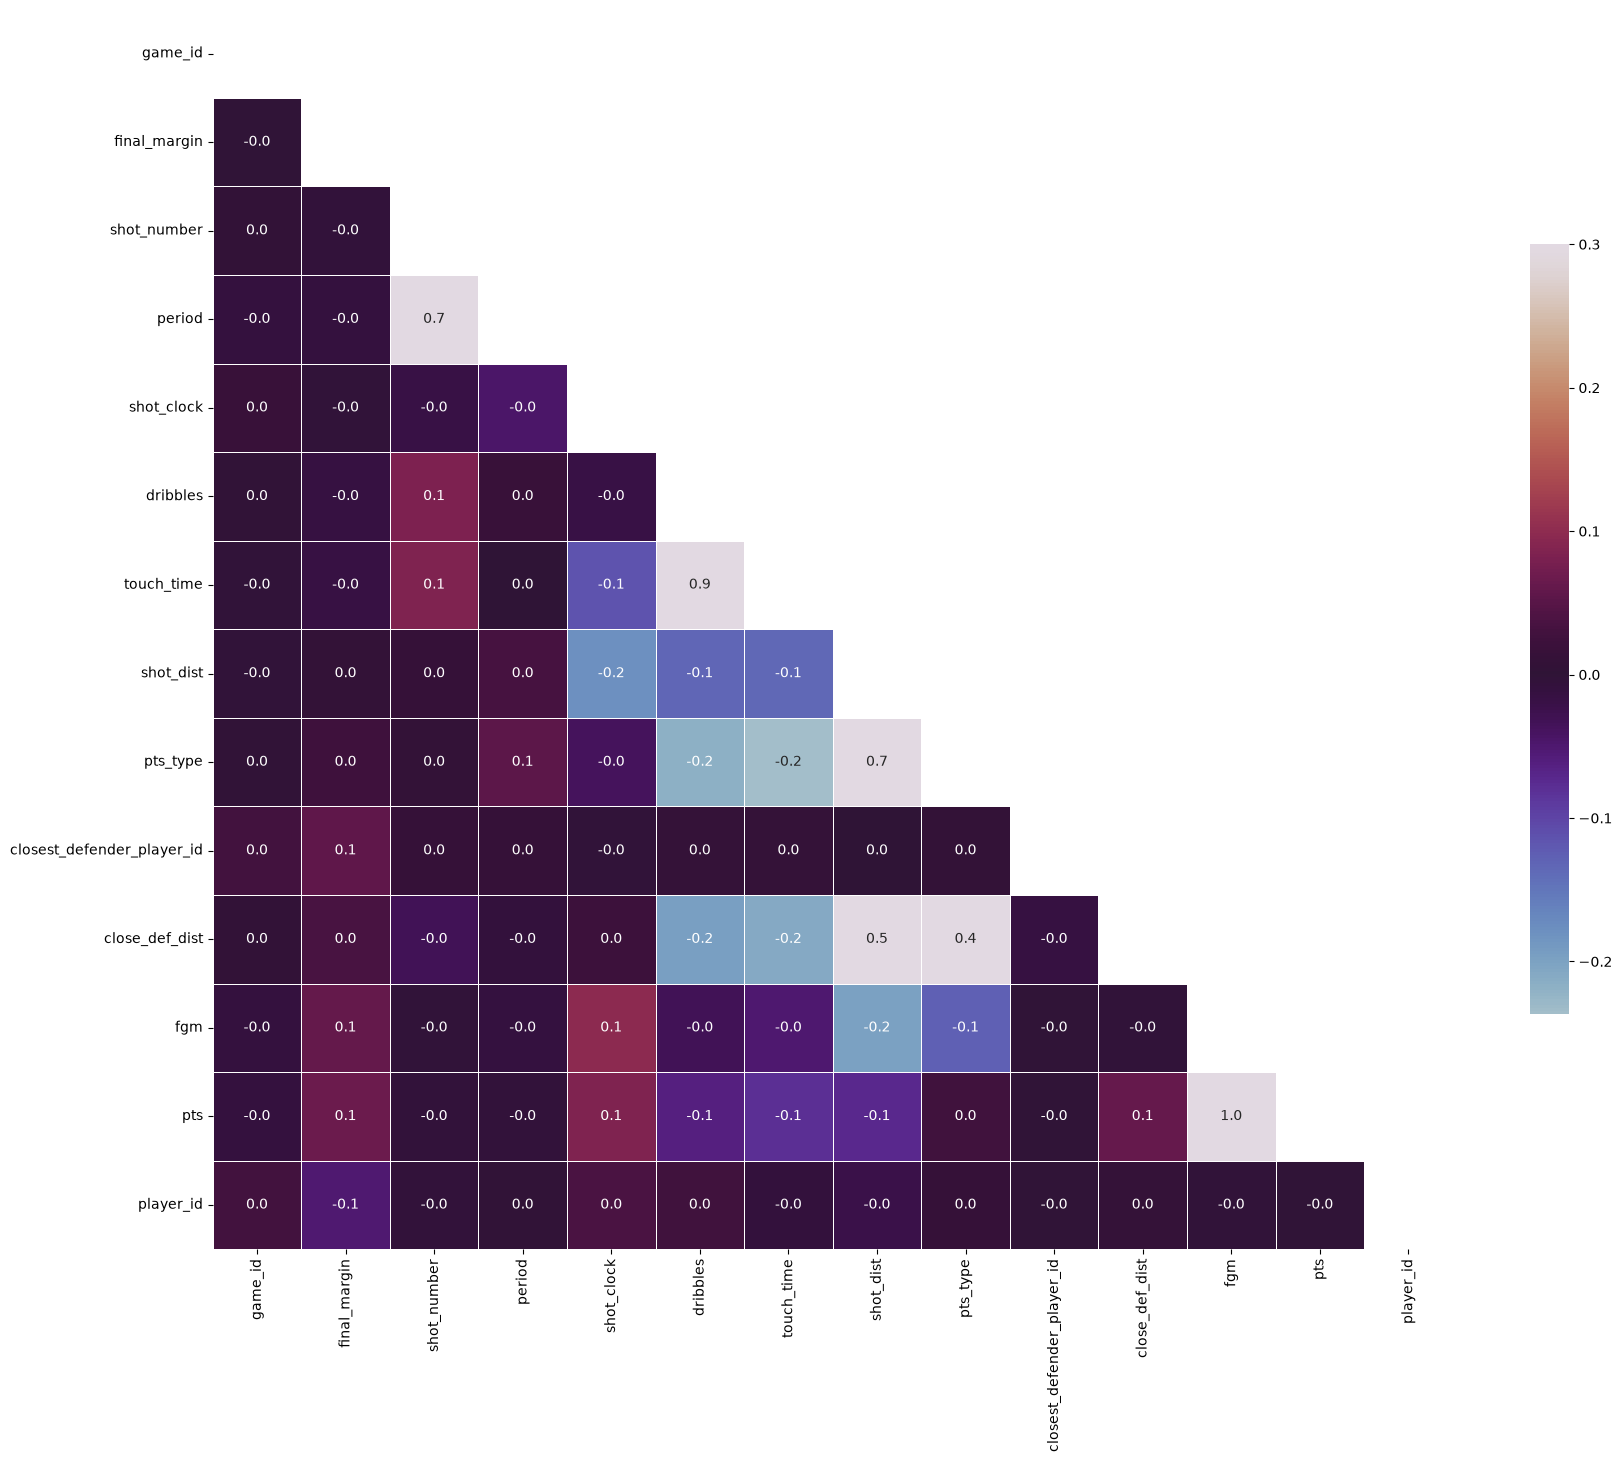

In [3]:
shotlogs.columns = shotlogs.columns.str.lower()

Q1 = shotlogs['touch_time'].quantile(0.25)
Q3 = shotlogs['touch_time'].quantile(0.75)

IQR = Q3 - Q1

Lower_Whisker = Q1 -  1.5*IQR
Upper_Whisker = Q3 + 1.5*IQR

outliers = shotlogs[(shotlogs.touch_time < Lower_Whisker) | (shotlogs.touch_time > Upper_Whisker)]

shotlogs = shotlogs.drop(outliers.index)

outliers = shotlogs[(shotlogs.touch_time < 0)]
shotlogs = shotlogs.drop(outliers.index)

shotlogs['date'] = shotlogs['matchup'].str[:12]
shotlogs['date'] = pd.to_datetime(shotlogs['date'], format='%b %d, %Y')

corr = shotlogs.corr(numeric_only=True)

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(20, 20))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, annot = True, fmt=".1f", mask=mask, cmap='twilight', vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

### Analysis

There is a healthy amount of setup required to work with this dataset. Let's analyze some of the steps the user took to simplify or wrangle this data before creating this visualization:

- Converting column names from all caps to lowercase: this makes it much more convenient to use variable names in lines of code, also a very efficient one line fix using the columns.str.lower() function
- Removal of outliers: the user detected outliers in the touchtime category (namely negative values that are clearly errors) and removed them from the dataset, so as not to sabotage our correlation scores
- Mask generation: our correlation matrix is symmetric (callback to linear algebra), so this line of code masks the upper triangle to hide repeated values, giving us the "staircase" pattern we see above

It's clear that the author of this data journal is a very talented and knowledgeable coder, but I feel like there could be many improvements made to this graph. Let's make the following changes:

1. Trim down variables to ones of interest
2. Rename columns to be more visually understandable and appealing
3. Redo the color scheme, so boldness of color indicates strength of relationship

## Creating The New Chart

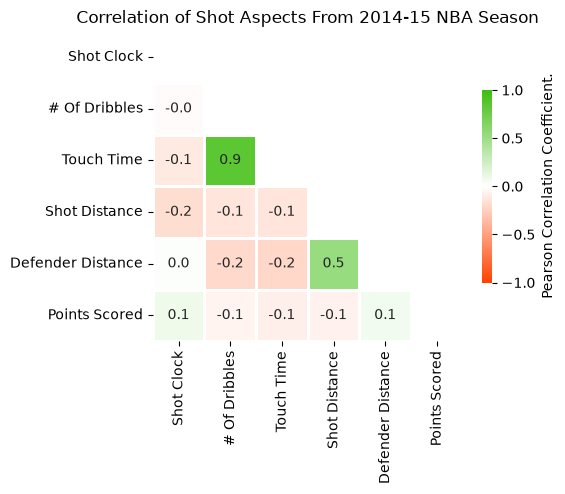

In [46]:
new_shotlogs = shotlogs[['shot_clock', 'dribbles', 'touch_time', 'shot_dist', 'close_def_dist', 'pts']]

new_shotlogs = new_shotlogs.dropna()

new_shotlogs = new_shotlogs.rename(columns = {
    "shot_clock": "Shot Clock",
    "dribbles": "# Of Dribbles",
    "touch_time": "Touch Time",
    "shot_dist": "Shot Distance",
    "close_def_dist": "Defender Distance",
    "pts": "Points Scored"
})

new_corr = new_shotlogs.corr(numeric_only=True)

mask = np.triu(np.ones_like(new_corr, dtype=bool))

f, ax = plt.subplots(figsize=(5, 5))

colors = ["#ff4200", "#ffffff", "#3ebd0e"]
custom_cmap = LinearSegmentedColormap.from_list("custom_scale", colors)

sns.heatmap(new_corr, annot = True, fmt=".1f", mask=mask, cmap = custom_cmap, vmax=1, vmin = -1, center=0,
            square=True, linewidths=1, cbar_kws={"label": "Pearson Correlation Coefficient.", "shrink": .5})

plt.title("Correlation of Shot Aspects From 2014-15 NBA Season")
plt.show()

## Reflection

Let's reflect on what was mainly wrong with the original chart, what we changed, and how the new chart accomplishes this goal better.

### Original Chart

The original chart, while it involved some very high-level wrangling and compilation to create, struggled from an overload of visual clutter and some malinformed design choices. Firstly, the user should've reduced the variable list to a smaller group of variables that would be of interest for analyzing correlation or, at the very least, removed index variables such as game data, player ID, and match result. Also, these variables were left in their raw forms, which made reading the actual chart kind of a headache. Finally, my last issue with this original chart was their choice of color scale, which did effectively differentiate between position and negative linear relationships, but didn't use the weight or opacity of color to describe the strength of the relationship. In fact, low correlations were coded using a dark black, which I thought was counterintituive.

### New Chart: What I Changed

Firstly, I reduced the scale of the graph through several measures. I reduced our dataset to 6 variables (shot clock, # of dribbles, touch time, shot distance, defender distance, and points scored), all of which are quantitative variables that I (as a basketball fanatic) would expect to observe some kind of correlation between. I also renamed these variables to more detailed and neat titles, so that the chart would be more readable. After that, I quickly designed a new color scale for our heatmap; by using a gradient that fades to white the smaller the magnitude of the value as well as green/red to decode positive/negative, I believe this scale is a very intuitive way of decoding the significance of a Pearson correlation coefficient. Finally, I made several small tweaks to the heatmap itself, such as:

- Adding titles to the plot and legend
- Adjusting size so plot can be viewed without scrolling
- Changing maximum and minimum values of the legend so it dispays the full range of corr. coef. values
- Aesthetic changes such as linewidth and legend size

### Overall Reflection on the Chart and Graphics

Overall, I would say this chart, at least based on the result, is a bit logically flawed. We don't observe more than 1 significant correlation between our variables (one we would expect, number of dribbles taken and length of possession should go together), and while it was interesting to investigate potential correlations, there is so much variety on the player, game, and shot-by-shot basis that it would be impossible to find correlations between variables that aren't directly related from the beginning. However, I believe the heatmap is the perfect visualization to diagnose potential relationships between large groups of variables in a dataset, so I still think this was a prudent exercise.

More holistically, doing this exercise taught me how small tweaks and minor changes in code can make large differences in the final result. A quick redesign of the colorset created a far more intuitive decoding of the correlation coefficient, tweaks to the legend better described what we were seeing, and easy reductions from the variable set limited our graph to only variables of interest (reducing visual clutter). In totality, these edits created a graphic that is more visually appealing, aptly cleaned, and easily understandable than our original.